# HW Tool

## 1. `shap.plots.beeswarm` нормального человека (6 баллов)

Как вы могли видеть, у встроенного beeswarm plot`а есть несколько недостатков:
- нет информации о том, какие именно значения категориальных признаков в какую сторону толкают предсказания модели
- иногда серые точки (пропущенные значения) прячутся за точками другого цвета -> их не видно (см. rooms_num на графике с семинара)
- иногда раскраска бывает некорректной (потому что она раскрашивает по абсолютным значениям)

Вам предлагается реализовать свою версию shap.plots.beeswarm, которая исправляет эти недостатки.


Итак, требуется написать функцию, которая принимает на вход shap_values и все необходимое и строит по этим данным beeswarm plot
    без вышеперечисленных недостатков, а именно:
- теперь все уникальные значения кат. фич становятся как бы отдельными фичами, по ним видны shap_values (см. пример)
    - чтобы не захламлять ваш график редковстречающимися категориями, принимайте на вход параметр, чтобы контролировать это
    - такие фичи должны быть покрашены в особый цвет, чтобы отличаться от числовых
- точки, отвечающие за наны, должны быть хорошо видны на фоне остальных и не перекрывать их
- раскраска должна адекватно красить ваши точки
    - можно выкидывать выбросы перед покраской
    - можно логарифмировать значения
    - можно красить по квантилям, а не по абсолютным значениям
    - лучше всего красятся равномерное и нормальное распределение

**Обязательно:**
- docstring
- комменты к непонятным кускам кода - что там происходит
- принимайте на вход кол-во фич, которые вы отображаете на графике
- принимайте на вход размер фигуры
- нарисуйте вертикальную линию, обозначающую 0
- сортируйте признаки по среднему модулю shap_values
- используйте stripplot (или аналоги) с jitter`ом, а не swarmplot
- принимайте на вход кол-во точек которое будете отрисовывать (500-3000 = норм)
    - если для какого-то значения кат фичи точек меньше, чем вы задали, рисуйте сколько есть

**!**
Если на вход подана слишком большая выборка, вы можете под капотом сэмплить из нее какое-то адекватное кол-во точек и отрисовывать их.
Однако, раскраску и контроль за отрисовкой категорий лучше базировать на всей выборке, поданной на вход.


Ниже приведен пример. Не меняйте код, предшествующий примеру. Вы не обязаны повторять пример точь-в-точь, это ориентир. Не удаляйте пример.

Удачи!

In [132]:
import numpy as np, pandas as pd
import lightgbm as lgb
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from sklearn.preprocessing import quantile_transform
%load_ext autoreload
%autoreload 2


df = pd.read_parquet('train_sber.parquet')
features = df.columns.drop(['timestamp', 'result_price', 'result_price_bin'])

model = lgb.Booster(model_file='model.lgb')
shap_values = model.predict(df[features], pred_contrib=True)

'''
Учтите, что если вы считаете shap_values через LightGBM,
    shap_values - np.array of shape (N, F + 1), где последний столбец - константа = среднее предсказание для всех объектов
'''
print('features shape:', features.shape, 'shap_values shape:', shap_values.shape)
df.head(3)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
features shape: (36,) shap_values shape: (27232, 37)


,district_area,road_distance_1,road_distance_2,year_of_construction,bulvar_ring_km,bus_station_distance,cafe_count,fitness_center_distance,floor,district_population,...,public_transport_station_distance,sadovoe_km,base_school_distance,sport_count,state,district_name,timestamp,malls_count,railway_station_distance,result_price_bin
0,6407578.100,1.422391,3.830951,NaN,13.675657,24.292406,152,0.485841,4.0,86206,...,3.299822,13.100618,0.177975,52,NaN,Bibirevo,2011-08-20,52,14.231961,False
1,9589336.912,2.887377,3.103996,NaN,8.132640,5.706113,177,0.668364,3.0,76284,...,0.783160,6.444333,0.273345,66,NaN,Nagatinskij Zaton,2011-08-23,40,9.242586,False
2,4808269.831,0.647250,2.927487,NaN,8.054252,6.710302,122,0.733101,2.0,101982,...,3.945073,6.963403,0.158072,67,NaN,Tekstil'shhiki,2011-08-27,35,9.540544,False


In [160]:
def my_beeswarm(df: pd.DataFrame, features: list, 
                cat_feature_threshold: float =0.001, shap_values: np.ndarray =shap_values, 
                top_k: int =13, figsize: tuple =(10, 6), dots: int =1000) -> None:
    """Функция для отрисовки кастомного shap.beeswarm. Принимает на вход исходные данные, список фичей
    для отрисовки, уже посчитанные shap_values, параметры графика, и рисует топ значимых фичей по 
    абсолютному среднему шапу.

    Args:
        df (pd.DataFrame): Таблица данных, на основе которой считались shap values
        features (list): Список признаков, для которых рассчитывалиь shap values, и 
                        которые будут визуализированы
        cat_feature_threshold (float, optional): Минимальный размер категории, чтобы рассматривать
                        ее как отдельный признак. Defaults to 0.001.
        shap_values (np.ndarray, optional): Список shap values, для списка переданных фичей и объектов выборки. 
                                            Defaults to shap_values.
        top_k (int, optional): Сколько фичей отобразить на графике. Отбираются исходя из топа среднего абсолютного шапа. 
                               Defaults to 13.
        figsize (tuple, optional): Размер графика. Defaults to (10, 6).
        dots (int, optional): Сколько максимум точек нужно отобразить для каждой фичи. Defaults to 1000.
    """
    shap_df = pd.DataFrame(shap_values[:, :-1], columns=features)
    df_tmp = df[features] # сразу убираем ненужные колонки из исходной таблицы

    # получаем список категориальных фичей
    categorical_features = features[df_tmp[features].dtypes == 'category']

    # считаем средний шап для числовых фичей
    mean_abs_shap_non_categorical = shap_df.drop(categorical_features, axis=1).abs().mean(axis=0)
    feature_names_non_categorical = mean_abs_shap_non_categorical.index.values
    feature_abs_shaps_non_categorical = mean_abs_shap_non_categorical.values

    # Разделяем категориальные колонки по категориям в них, для каждой категории генерируем новое название,
    # достаем для нее ее список shap_values.
    categorical_shap_values = {} # для каждой категории тут будем хранить список шап значений
    cat_feature_names = [] # здесь будем хранить названия новых фичей
    cat_shaps = [] # здесь храним средний абсолютный шап категории
    for cat_feat in categorical_features:
        # для каждой категории категориальной колонки считаем ее вес в исходной выборке.
        # отбираем те категории, чей вес достаточен (больше cat_feature_threshold)
        unique_cat_features = df_tmp[cat_feat].value_counts(normalize=True) 
        significant_caregories = unique_cat_features[unique_cat_features > cat_feature_threshold].index
        significant_indeces = np.where(df_tmp[cat_feat].isin(significant_caregories))[0]
        
        # группируем данные по значительным категориям, из каждой группы достаем список шап значений
        # генерируем название новой фичи, высчитываем ее средний абсолютный шап 
        for category, group in df_tmp.iloc[significant_indeces].groupby(cat_feat, observed=True):
            category_shap_values = shap_df[cat_feat].loc[group.index].values
            category_name = '_'.join([cat_feat, category])
            categorical_shap_values[category_name] = category_shap_values
            cat_feature_names.append(category_name)
            cat_shaps.append(np.abs(category_shap_values).mean())

    # объединяем список названий числовых и категориальных фичей, а так же средние значения шапа
    new_features = np.append(feature_names_non_categorical, cat_feature_names)
    mean_shaps = np.append(feature_abs_shaps_non_categorical, cat_shaps)

    # сортируем по среднему абсолютному шапу, отбираем top_k фичей
    sorted_shap_inds = np.argsort(mean_shaps)[::-1]
    top_feature_names = new_features[sorted_shap_inds][:top_k]

    cat_feature_names = set(cat_feature_names)

    top_shap_data = {} # здесь будем хранить шап значения для топ фичей
    palette = {} # здесь будем хранить раскраску для сэмплов из топ фичей

    cmap = cm.ScalarMappable(norm=mcolors.Normalize(vmin=0, vmax=1), cmap='coolwarm')
    cmap.set_array([])

    for top_name in top_feature_names:
        if top_name in categorical_shap_values:
            # отбираем не более dots точек из имеющихся в данной фиче
            current_feature_shaps = categorical_shap_values[top_name]
            top_shap_data[top_name] = np.random.choice(current_feature_shaps, size=min(dots, len(current_feature_shaps)), replace=False)

            # сохраняем цвет для категориальной фичи (у них цвета одинаковые)
            palette[top_name] = np.array([[0, 1, 0, 1]] * len(top_shap_data[top_name]))
        else:
            # отбираем не более dots точек из имеющихся в данной фиче
            current_feature_shaps = shap_df[top_name].values
            inds = np.random.choice(np.arange(len(current_feature_shaps)), size=min(dots, len(current_feature_shaps)), replace=False)
            top_shap_data[top_name] = current_feature_shaps[inds]

            # Обрабатываем числовые данные. Переводим в квантили
            chosed_samples = df_tmp.iloc[inds][top_name].astype(float)
            chosed_samples = pd.Series(quantile_transform(chosed_samples.values.reshape(-1, 1), n_quantiles=100).reshape(-1))

            # нормируем данные мин-максом. сохраняем цвета.
            scaled_samples = (chosed_samples.values - chosed_samples.min()) / (chosed_samples.max() - chosed_samples.min())
            palette[top_name] = cmap.to_rgba(scaled_samples)
    
    plt.figure(figsize=figsize)
    plt.axvline(0, c='m', linewidth=1, zorder=1)

    for i, feature in enumerate(top_feature_names[::-1]):
        # разделяем объекты на те, у которых наны в данном признаке, и у которых все ок
        nan_mask = palette[feature].sum(axis=1) == 0
        not_nan_mask = ~nan_mask

        # точки с нанами отрисовываем черным
        nan_shaps = top_shap_data[feature][nan_mask]
        plt.scatter(nan_shaps, np.full_like(nan_shaps, i) + np.random.uniform(-0.01, 0.01, size=len(nan_shaps)), 
                    c='black', alpha=0.7, s=5, zorder=3)

        # точки не с нанами отрисовываем обычно
        non_nan_shaps = top_shap_data[feature][not_nan_mask]
        plt.scatter(non_nan_shaps, np.full_like(non_nan_shaps, i) + np.random.uniform(-0.2, 0.2, size=len(non_nan_shaps)), 
                c=palette[feature][not_nan_mask], alpha=0.7, s=5, zorder=2)

    # устанавливаем названия фичей координаты y
    plt.yticks(ticks=np.arange(len(top_feature_names)), labels=top_feature_names[::-1])

    # рисуем серые линии вдоль фичей
    for y_pos in top_feature_names:
        plt.axhline(y=y_pos, color='gray', linestyle='-', linewidth=1, alpha=0.7, zorder=1)

    plt.xlabel("Contribution")
    plt.ylabel("Feature")

    plt.colorbar(cmap, orientation='vertical', ax=plt.gca())

    plt.tight_layout()
    plt.show()

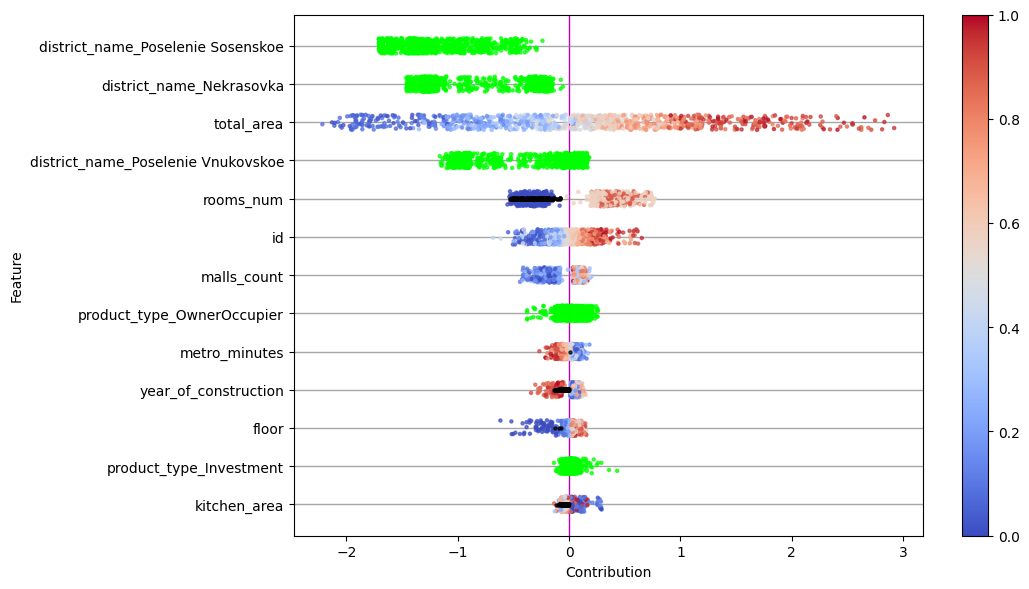

CPU times: user 443 ms, sys: 219 ms, total: 662 ms
Wall time: 325 ms


In [161]:
%%time

my_beeswarm(df, features, cat_feature_threshold=0.03, shap_values=shap_values, top_k=13, figsize=(11, 6), dots=1000)

Пример ниже. Не удаляйте пример!

CPU times: total: 1.61 s
Wall time: 1.61 s


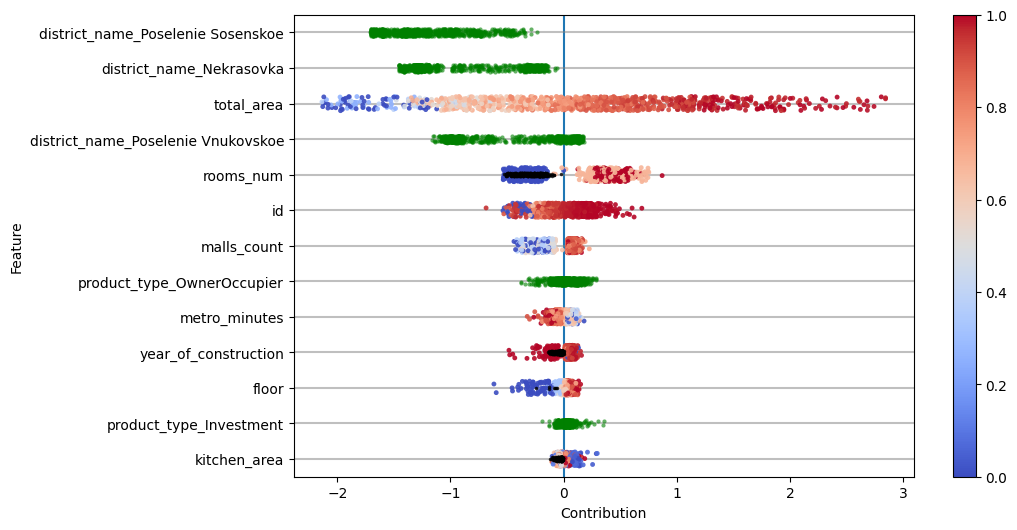

In [28]:
%%time
from utils import shap_beeswarm

shap_beeswarm(model, df, features, cat_feature_threshold=0.001, shap_values=shap_values, top_k=13, figsize=(10, 6), dots=1000)

## 2. Логирование градиентов при обучении (4 балла)

**Задача:** хотим для каждого объекта для каждого дерева получить gi - производную лосса!
Чтобы:
- нарисовать карту объект-дерево
- поизучать 2D-представления
- призадуматься...

**Как:** придумайте способ! Нужно в процессе обучения сохранять градиенты LogLoss`а объектов на каждом дереве, после чего продемонстрировать собранные градиенты с помощью sns.clustermap. 

Ниже пример. Не удаляйте пример!

In [44]:
class GradientCollector:
    def __init__(self):
        self.gradients = []
        self.is_collecting = False
        
    def create_custom_objective(self):
        collector = self
        
        def custom_obj(preds, train_data):
            labels = train_data.get_label()

            preds_prob = 1.0 / (1.0 + np.exp(-preds))
            grad = preds_prob - labels
            hess = preds_prob * (1.0 - preds_prob)

            if collector.is_collecting:
                collector.gradients.append(grad.copy())
                
            return grad, hess
        
        return custom_obj
    
    def get_gradient_matrix(self) -> pd.DataFrame:
        if not self.gradients:
            raise ValueError("No gradients found.")
        
        grad_matrix = np.vstack(self.gradients)
        
        return grad_matrix


def collect_gradients(
    data: lgb.Dataset,
    params = None,
    num_boost_round: int = 100
    ):
    if params is None:
        params = params = {
            'objective': 'binary',
            'metric': 'binary_logloss',
            'boosting_type': 'gbdt',
            'learning_rate': 0.1,
            'num_leaves': 31,
            'feature_fraction': 0.8,
            'bagging_fraction': 0.8,
            'bagging_freq': 5,
            'verbose': -1
        }

    collector = GradientCollector()

    params_copy = params.copy()
    params_copy['objective'] = collector.create_custom_objective()
    params_copy['num_iterations'] = num_boost_round
    collector.is_collecting = True
    
    model = lgb.train(
        params_copy,
        data,
        num_boost_round=num_boost_round
    )
    
    collector.is_collecting = False
    
    gradient_matrix = collector.get_gradient_matrix()
    
    return model, gradient_matrix

Пример. Не удаляйте пример!

In [45]:
def get_split(df, val_size=0.33):
    train_idx = np.random.choice(df.index, size=int(df.shape[0]*(1-val_size)), replace=False)
    val_idx = np.setdiff1d(df.index, train_idx)
    return df.loc[train_idx].reset_index(drop=True), df.loc[val_idx].reset_index(drop=True)

tr, val = get_split(df, val_size=0.23)
lgb_tr = lgb.Dataset(tr[features], tr.result_price_bin)

_, grads = collect_gradients(lgb_tr)
grads.shape

(100, 20968)

### Моя реализация

CPU times: user 44 s, sys: 1.76 s, total: 45.8 s
Wall time: 45.5 s


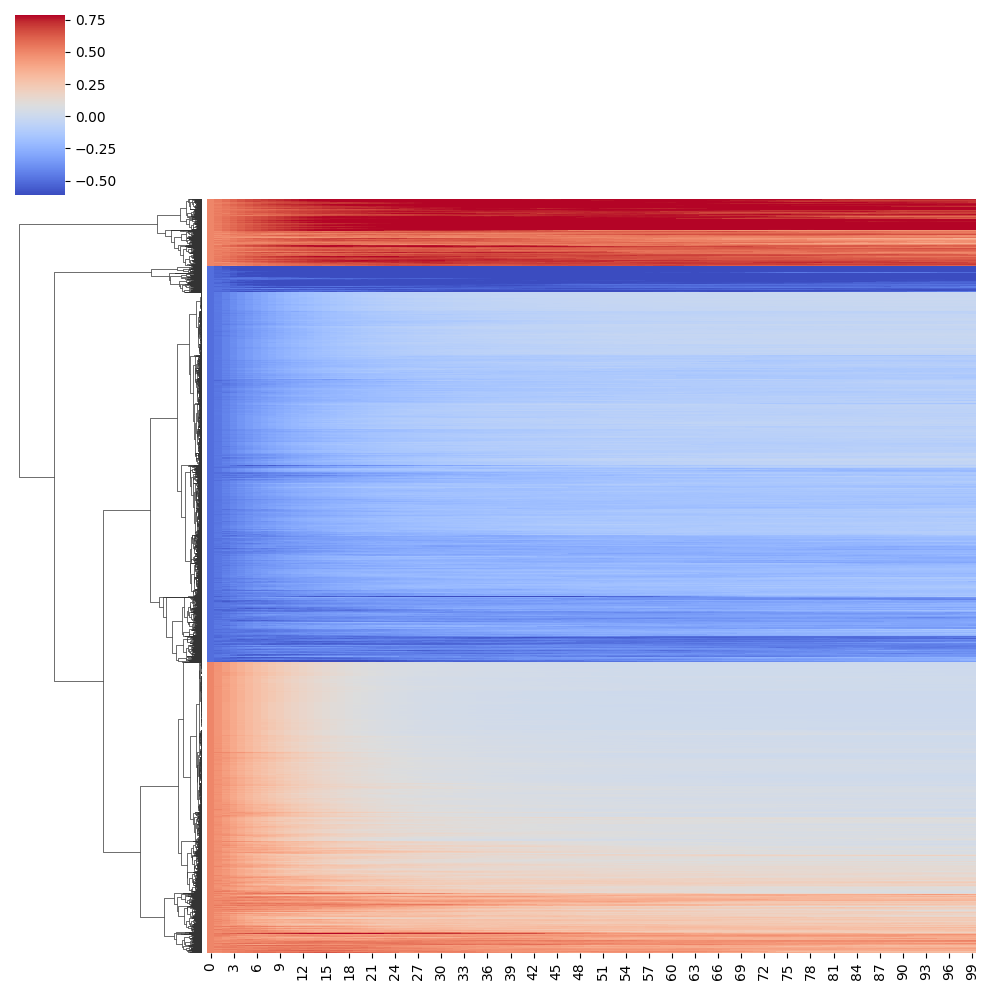

In [ ]:
%%time
import seaborn as sns

sns.clustermap(grads.T, col_cluster=False, robust=True, yticklabels=False, cmap='coolwarm')

### Пример

CPU times: total: 1min 17s
Wall time: 1min 17s


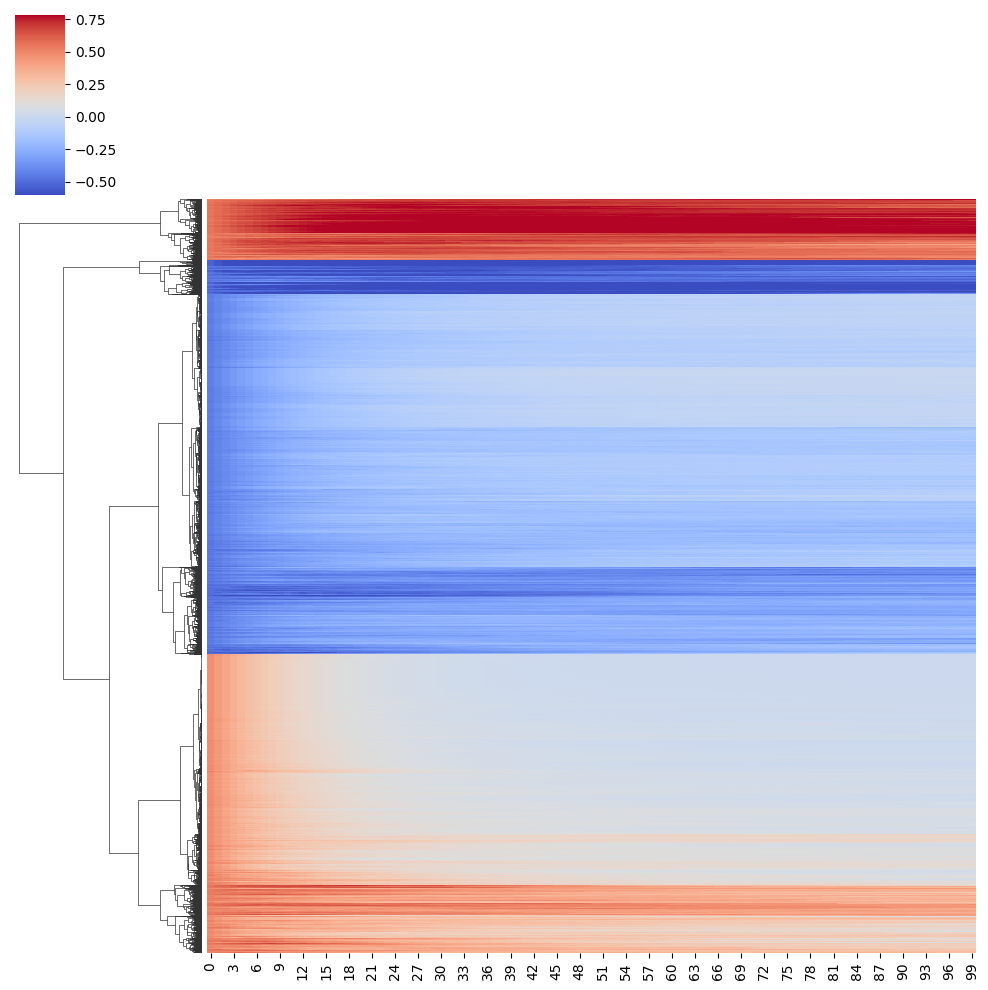

In [102]:
%%time
import seaborn as sns

# предварительно установите fastcluster: pip install fastcluster, иначе считаться будет долго
sns.clustermap(grads.T, col_cluster=False, robust=True, yticklabels=False, cmap='coolwarm')

## 3. Автоматическое создание весов для бинарной классификации (5 баллов)

В этом блоке ваша цель - написать функцию, которая генерирует вектор весов для объектов обучающей выборки следующим образом:
1) на вход подается таргет-колонка и произвольная колонка
2) если колонка числовая, бьем ее на бины (кол-во бинов `bins` принимаем на вход. берем небольшое, около 7-13)
    - если в колонке < `bins` уникальных, бить не надо 
3) если колонка категориальная, тоже бьем ее на бины
    - если уникальных значений <= `bins`, то за бины считаем уникальные значения категории
    - если уникальных значений >  `bins`, то выбираем `bins` - 1 самых популярных категорий у объектов класса 1
    - не попавшие в топ самых популярных категории запихиваем в бин 'other'

4) проходимся по всем бинам, присваивая всем объектам класса 1, попавшим в бин, вес n_0_in_bin / n_1_in_bin,
       если объектов класса 0, попавших в этот бин, достаточное кол-во (принимайте на вход, зависит от задачи)

5) всем объектам класса 0 присваиваем вес, равный единице

Такая схема на практике работает лучше, чем обычный `scale_pos_weight` параметр в LightGBM и его аналоги, если разумно выбирать
    вспомогательную колонку. Подумайте, как именно нужно выбирать такую колонку. Ответ писать не обязательно, но можно :)

**Обязательно:**
Найдите способ продемонстрировать визуализацией, что ваша функция работает корректно!

In [70]:
def scale_pos_weights(target, column, bins=10, min_class_0_count=5):
    weights = np.ones(len(target))
    
    if pd.api.types.is_numeric_dtype(column):
        unique_values = column.unique()

        if len(unique_values) < bins:
            array_bin = column.values
        else:
            array_bin = pd.qcut(column, q=bins, labels=False, duplicates='drop')
        
    else:
        value_counts = column.value_counts()
        unique_values = value_counts.index
        
        if len(unique_values) <= bins:
            array_bin = column.values
        else:
            top_categories = value_counts.nlargest(bins - 1).index
            array_bin = column.map(lambda x: x if x in top_categories else 'other')
    
    df_bins = pd.DataFrame({'target': target, 'bin': array_bin})

    bin_counts = df_bins.groupby('bin', observed=True).agg(n_0=('target', lambda x: (x == 0).sum()),
                                             n_1=('target', lambda x: (x == 1).sum())).reset_index()
    
    for _, row in bin_counts.iterrows():
        if row['n_1'] > 0 and row['n_0'] >= min_class_0_count:
            weight_value = row['n_0'] / row['n_1']
            weights[(df_bins['bin'] == row['bin']) & (target == 1)] = weight_value
    
    return weights

In [ ]:
df2 = df[['healthcare_centers_count', 'road_distance_1', 'product_type', 'district_name', 'result_price_bin']]

Проверим корректность фукции

In [ ]:
groupby_ratio = df2.groupby('healthcare_centers_count').agg(
    ratio=pd.NamedAgg(column='result_price_bin', aggfunc=lambda x: np.sum(1 - x) / np.sum(x))
)
scales = scale_pos_weights(df2['result_price_bin'], df2['healthcare_centers_count'])
df_tmp = pd.DataFrame(data=np.array([scales, df2['healthcare_centers_count'].values, df2['result_price_bin']]).T, columns=['scale', 'column', 'target'])

ratio_calced = df_tmp[df_tmp['target'] == 1].groupby('column').agg(
    weight=pd.NamedAgg(column='scale', aggfunc='mean')
)

Более того, мы тут можем проверить корректность работы следующим образом. Средний таргет для категории это $\text{mean} = \frac{n_1}{n_0+n_1} \to \text{weight}=\frac{n_0}{n_1} = \frac{1}{\text{mean}} - 1$

In [222]:
means = df2.groupby('healthcare_centers_count').agg(
    mean=pd.NamedAgg(column='result_price_bin', aggfunc=lambda x: np.mean(x))
)
means

,mean
healthcare_centers_count,
0,0.377945
1,0.650606
2,0.583620
3,0.606904
4,0.681143
5,0.728407
6,0.706960


In [225]:
1 / means.values.reshape(-1) - 1

array([1.64588644, 0.53702745, 0.71344403, 0.64770642, 0.46812081,
       0.37285903, 0.41450777])

Сравним веса посчитанные моей функцией для позитивных сэмплов, и ground_truth

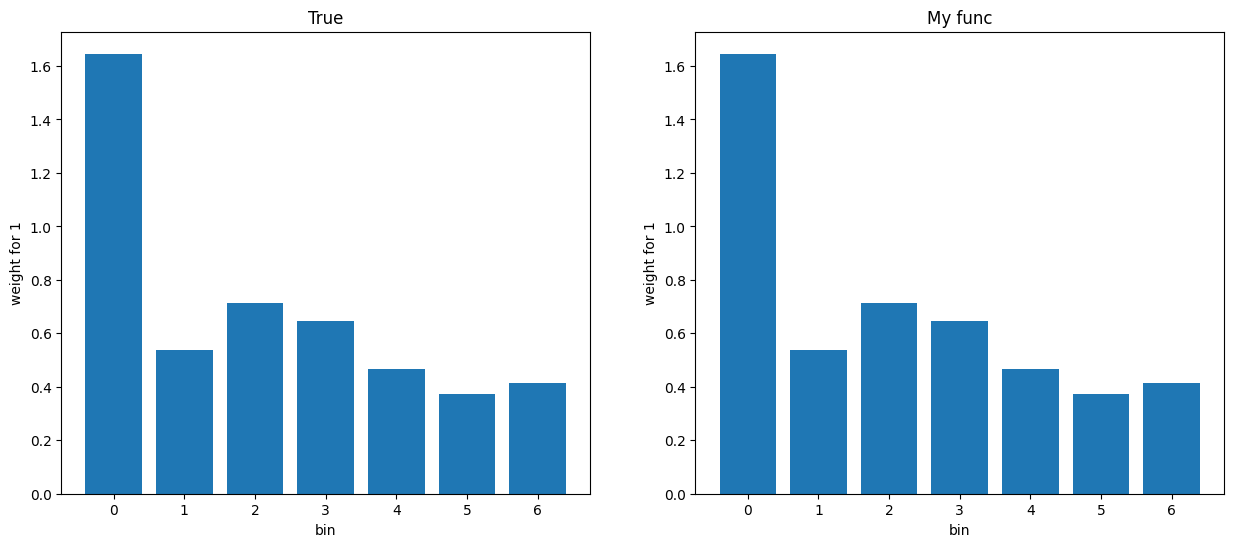

In [185]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].bar(groupby_ratio.index, groupby_ratio.values.reshape(-1))
axes[0].set_title('True')
axes[0].set_ylabel('weight for 1')
axes[0].set_xlabel('bin')
axes[1].bar(ratio_calced.index, ratio_calced.values.reshape(-1))
axes[1].set_title('My func')
axes[1].set_ylabel('weight for 1')
axes[1].set_xlabel('bin')
plt.show()

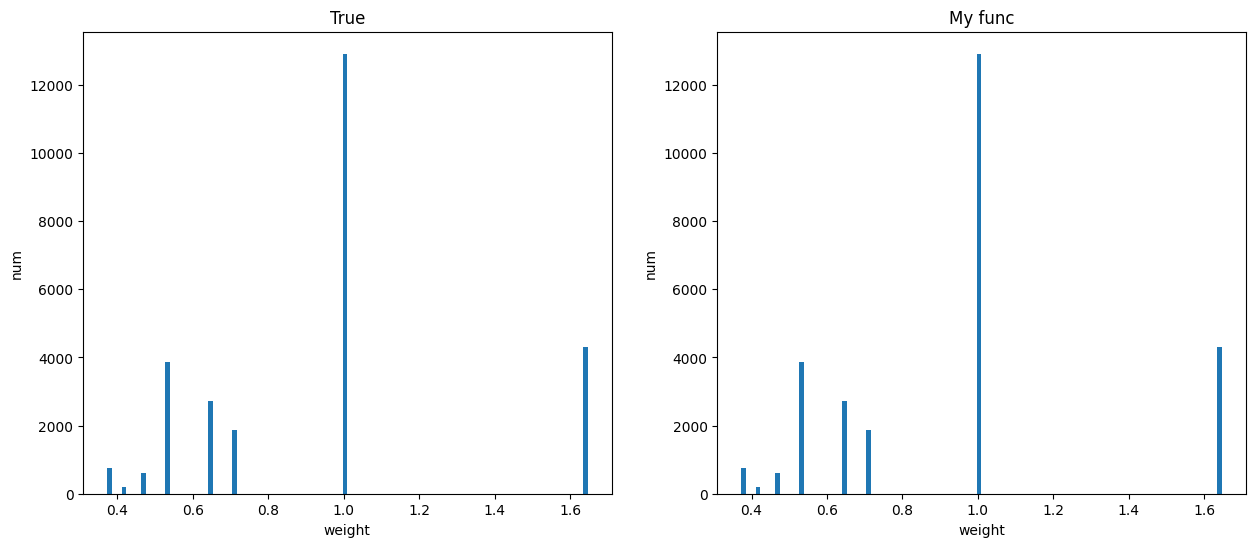

In [187]:
df2.loc[:, 'health_weight'] = df2.apply(lambda row: 1 if row['result_price_bin'] == 0 else groupby_ratio.loc[row['healthcare_centers_count']].values[0], axis=1)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].hist(df2['health_weight'].values, bins=100)
axes[0].set_title('True')
axes[0].set_xlabel('weight')
axes[0].set_ylabel('num')
axes[1].hist(scales, bins=100)
axes[1].set_title('My func')
axes[1].set_xlabel('weight')
axes[1].set_ylabel('num')
plt.show()

как видно из графиков, функция работает без ошибок. Ниже те же проверки, но для других колонок. Числовых и категориальных.

In [ ]:
scales = scale_pos_weights(df2['result_price_bin'], df2['road_distance_1'])
df_tmp = pd.DataFrame(data=np.array([scales, pd.qcut(df2['road_distance_1'], q=10, labels=False, duplicates='drop'), df2['result_price_bin']]).T, columns=['scale', 'column', 'target'])
groupby_ratio = df_tmp.groupby('column').agg(
    ratio=pd.NamedAgg(column='target', aggfunc=lambda x: np.sum(1 - x) / np.sum(x))
)
ratio_calced = df_tmp[df_tmp['target'] == 1].groupby('column').agg(
    weight=pd.NamedAgg(column='scale', aggfunc='mean')
)

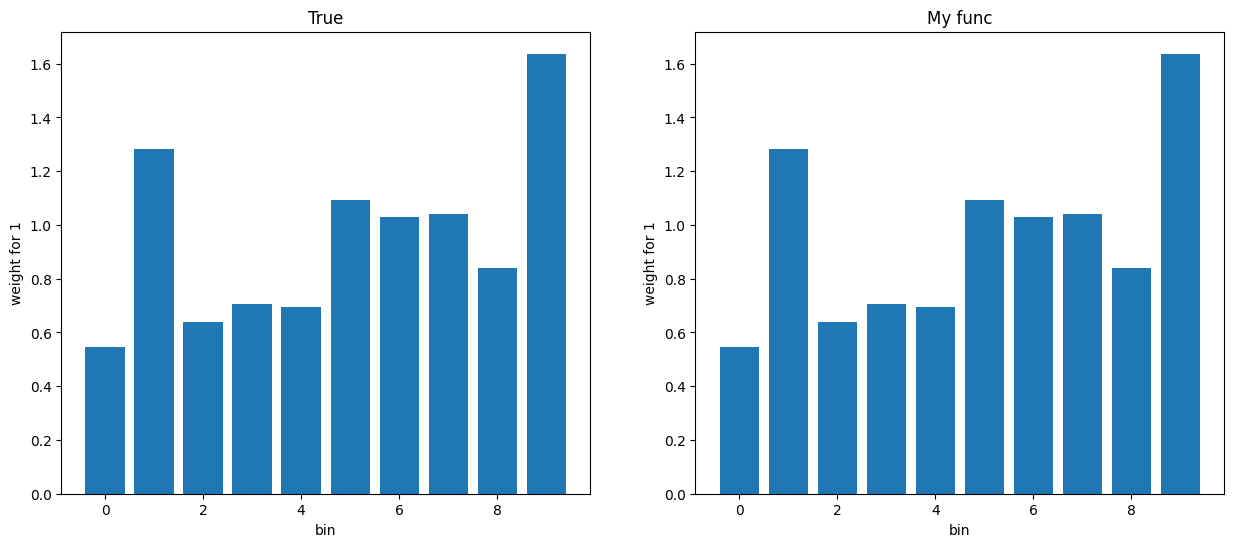

In [197]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].bar(groupby_ratio.index, groupby_ratio.values.reshape(-1))
axes[0].set_title('True')
axes[0].set_ylabel('weight for 1')
axes[0].set_xlabel('bin')
axes[1].bar(ratio_calced.index, ratio_calced.values.reshape(-1))
axes[1].set_title('My func')
axes[1].set_ylabel('weight for 1')
axes[1].set_xlabel('bin')
plt.show()

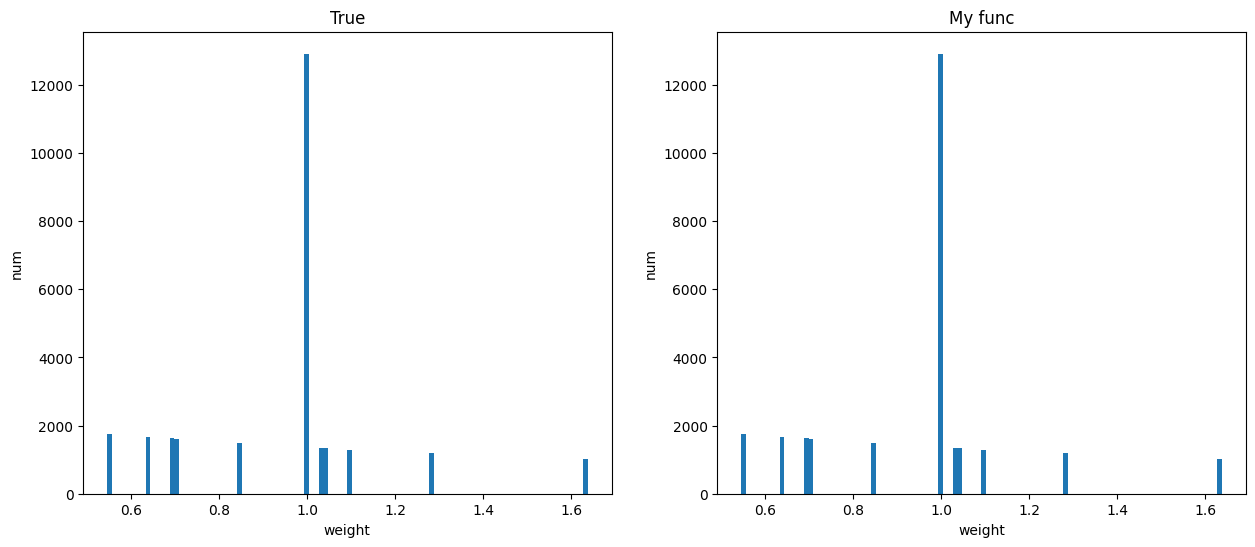

In [200]:
df2.loc[:, 'road_weight'] = df_tmp.apply(lambda row: 1 if row['target'] == 0 else groupby_ratio.loc[row['column']].values[0], axis=1)
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].hist(df2['road_weight'].values, bins=100)
axes[0].set_title('True')
axes[0].set_xlabel('weight')
axes[0].set_ylabel('num')
axes[1].hist(scales, bins=100)
axes[1].set_title('My func')
axes[1].set_xlabel('weight')
axes[1].set_ylabel('num')
plt.show()

In [201]:
groupby_ratio = df2.groupby('product_type').agg(
    ratio=pd.NamedAgg(column='result_price_bin', aggfunc=lambda x: np.sum(1 - x) / np.sum(x))
)
scales = scale_pos_weights(df2['result_price_bin'], df2['product_type'])
df_tmp = pd.DataFrame(data=np.array([scales, df2['product_type'].values, df2['result_price_bin']]).T, columns=['scale', 'column', 'target'])

ratio_calced = df_tmp[df_tmp['target'] == 1].groupby('column').agg(
    weight=pd.NamedAgg(column='scale', aggfunc='mean')
)

/tmp/ipykernel_208910/2977579129.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groupby_ratio = df2.groupby('product_type').agg(


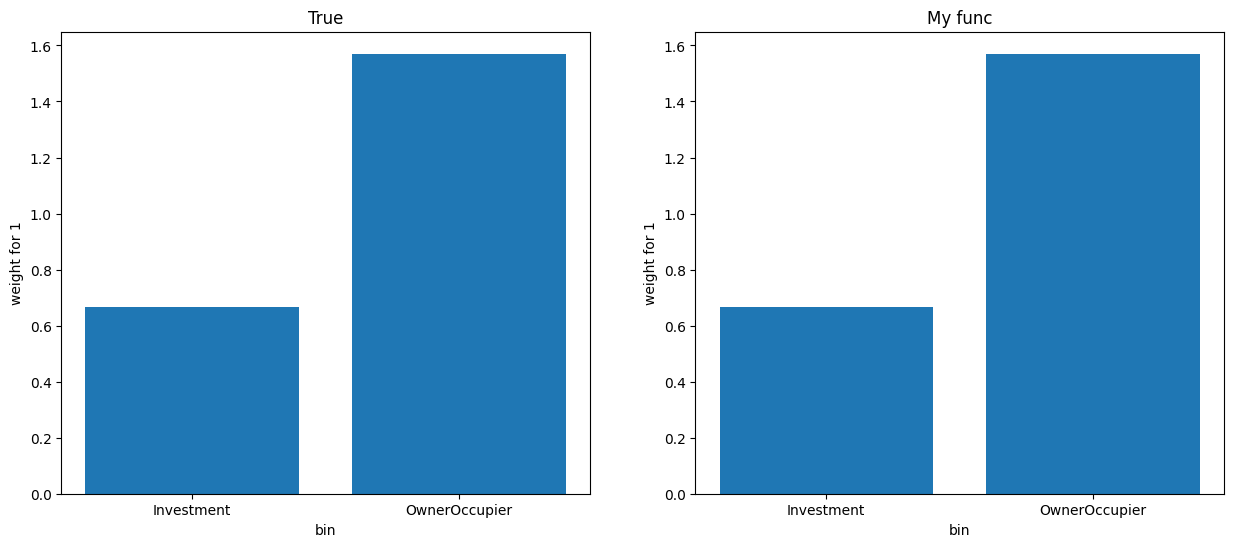

In [202]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].bar(groupby_ratio.index, groupby_ratio.values.reshape(-1))
axes[0].set_title('True')
axes[0].set_ylabel('weight for 1')
axes[0].set_xlabel('bin')
axes[1].bar(ratio_calced.index, ratio_calced.values.reshape(-1))
axes[1].set_title('My func')
axes[1].set_ylabel('weight for 1')
axes[1].set_xlabel('bin')
plt.show()

/tmp/ipykernel_208910/3281531905.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2.loc[:, 'product_weight'] = df2.apply(lambda row: 1 if row['result_price_bin'] == 0 else groupby_ratio.loc[row['product_type']].values[0], axis=1)


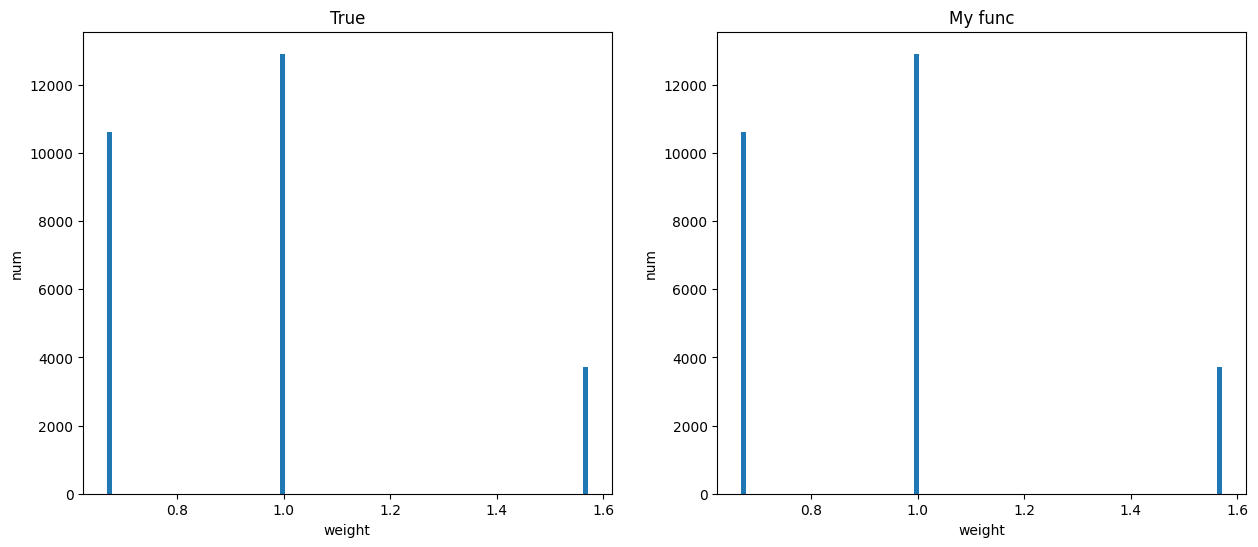

In [203]:
df2.loc[:, 'product_weight'] = df2.apply(lambda row: 1 if row['result_price_bin'] == 0 else groupby_ratio.loc[row['product_type']].values[0], axis=1)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].hist(df2['product_weight'].values, bins=100)
axes[0].set_title('True')
axes[0].set_xlabel('weight')
axes[0].set_ylabel('num')
axes[1].hist(scales, bins=100)
axes[1].set_title('My func')
axes[1].set_xlabel('weight')
axes[1].set_ylabel('num')
plt.show()

In [214]:
means = df2.groupby('product_type', observed=True).agg(mean=pd.NamedAgg(column='result_price_bin', aggfunc='mean'))
means

,mean
product_type,
Investment,0.599446
OwnerOccupier,0.389034


In [219]:
1 / means.values.reshape(-1) - 1

array([0.66820668, 1.57046618])

In [218]:
np.unique(scales)

array([0.66820668, 1.        , 1.57046618])

Как видно из посчитанных функцией весов, все работает корректно.

In [226]:
value_counts = df2['district_name'].value_counts()
top_categories = value_counts.nlargest(9).index
array_bin = df2['district_name'].map(lambda x: x if x in top_categories else 'other')

In [227]:
scales = scale_pos_weights(df2['result_price_bin'], df2['district_name'])
df_tmp = pd.DataFrame(data=np.array([scales, array_bin, df2['result_price_bin']]).T, columns=['scale', 'column', 'target'])
groupby_ratio = df_tmp.groupby('column').agg(
    ratio=pd.NamedAgg(column='target', aggfunc=lambda x: np.sum(1 - x) / np.sum(x))
)
ratio_calced = df_tmp[df_tmp['target'] == 1].groupby('column').agg(
    weight=pd.NamedAgg(column='scale', aggfunc='mean')
)

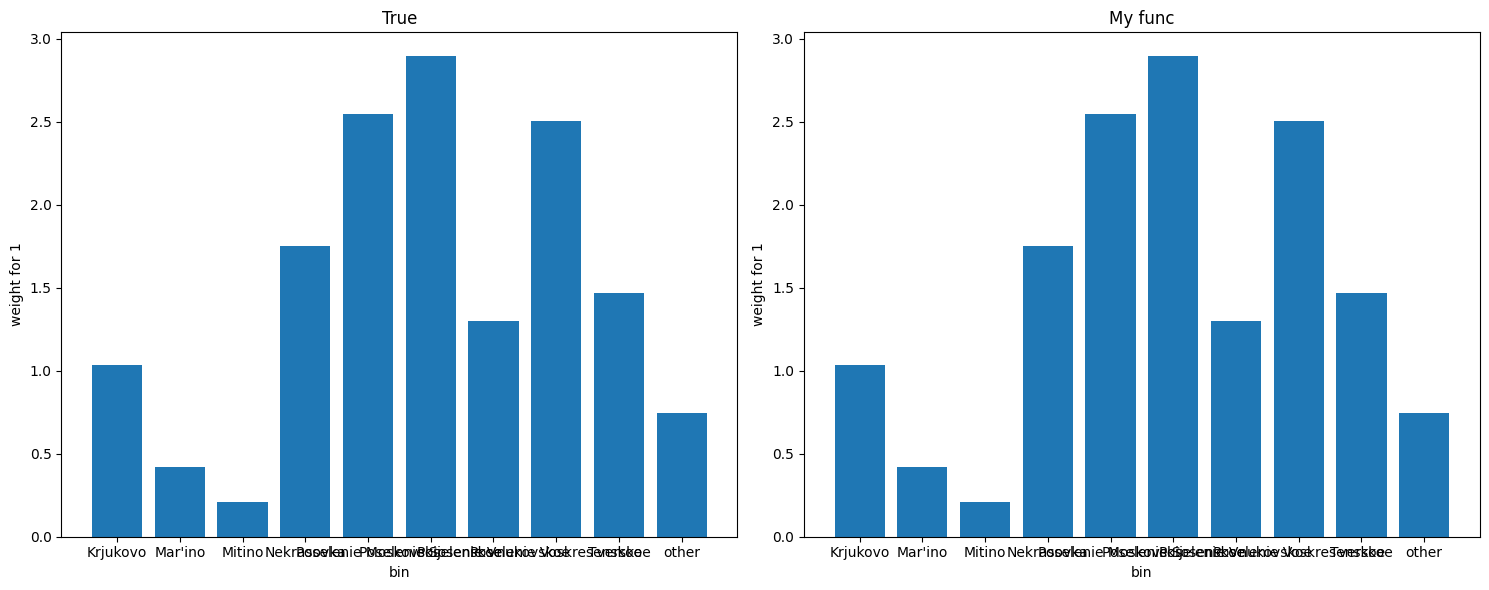

In [229]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

axes[0].bar(groupby_ratio.index, groupby_ratio.values.reshape(-1))
axes[0].set_title('True')
axes[0].set_ylabel('weight for 1')
axes[0].set_xlabel('bin')
axes[1].bar(ratio_calced.index, ratio_calced.values.reshape(-1))
axes[1].set_title('My func')
axes[1].set_ylabel('weight for 1')
axes[1].set_xlabel('bin')

plt.tight_layout()
plt.show()